In [1]:
import os, sys
os.environ.setdefault('CONDA_PREFIX', sys.prefix)
os.environ.get('CONDA_PREFIX')

'/opt/conda/envs/python3'

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import f1_score

In [3]:
import numpy as np
import pandas as pd

import cuml
import cupy as cp

In [4]:
import site
site.addsitedir("../dataprocessing")
from fakenews_functions import change_label

## Preparing data for use in machine learning model

In [5]:
data = pd.read_csv("../data/data_stemmed.csv", index_col=0)
metadata = pd.read_csv("../data/995,000_rows.csv", usecols=["type", "domain"])

In [6]:
data["type"] = metadata["type"].apply(change_label)
data["domain"] = metadata["domain"]

data.dropna(subset=["type"], inplace=True)
data.head()

,content,type,domain
0,plus one articl googl plus ( thank ali alfoneh...,1,nationalreview.com
1,cost best senat bank committe jp morgan buy : ...,0,beforeitsnews.com
2,man awoken <num> -year coma commit suicid lear...,0,dailycurrant.com
3,julia geist ask draw pictur comput scientist l...,1,nytimes.com
4,– <num> compil studi vaccin danger ( activist ...,0,infiniteunknown.net


In [7]:
# Shuffles data and splits it
data = data.sample(frac=1, random_state=0)

split_index1 = int(len(data)*0.8)
split_index2 = int(len(data)*0.9)

data_training = data[:split_index1]
data_validation = data[split_index1:split_index2]
data_testing = data[split_index2:]

In [8]:
vocab_list = pd.read_csv("../data/topwords10000.csv", index_col=0)
vocab_words = vocab_list.index.to_numpy()

In [9]:
vectorizer = CountVectorizer(vocabulary=vocab_words, dtype=np.float64)

In [10]:
X_train = vectorizer.transform(data_training["content"])
y_train = data_training["type"].astype(np.int64)

X_val = vectorizer.transform(data_validation["content"])
y_val = data_validation["type"].astype(np.int64)

X_test = vectorizer.transform(data_testing["content"])
y_test = data_testing["type"].astype(np.int64)

## Logistic regression model

In [11]:
model = cuml.LogisticRegression(max_iter=2500)

In [12]:
model.fit(X_train, y_train)

LogisticRegression()

### Model testing

In [13]:
pred_y = model.predict(X_test)
pred_y = cp.asnumpy(pred_y)

In [14]:
f1_score(y_test, pred_y, pos_label=1)

0.8506607878130431

## Logistic regression model with metadata

In [15]:
data["content_domain"] = data["content"] + " " + data["domain"]

In [16]:
data_training2 = data[:split_index1]
data_validation2 = data[split_index1:split_index2]
data_testing2 = data[split_index2:]

In [17]:
X_train2 = vectorizer.transform(data_training2["content_domain"])
y_train2 = data_training2["type"].astype(np.int64)

X_val2 = vectorizer.transform(data_validation2["content_domain"])
y_val2 = data_validation2["type"].astype(np.int64)

X_test2 = vectorizer.transform(data_testing2["content_domain"])
y_test2 = data_testing2["type"].astype(np.int64)

In [18]:
model2 = cuml.LogisticRegression(max_iter=2500)

In [19]:
model2.fit(X_train2, y_train2)

LogisticRegression()

### Testing model with metadata

In [20]:
pred_y_model2 = model2.predict(X_test2)
pred_y_model2 = cp.asnumpy(pred_y_model2)

In [21]:
f1_score(y_test2, pred_y_model2, pos_label=1)

0.8669183253260123

## Confusion matrices

In [23]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})

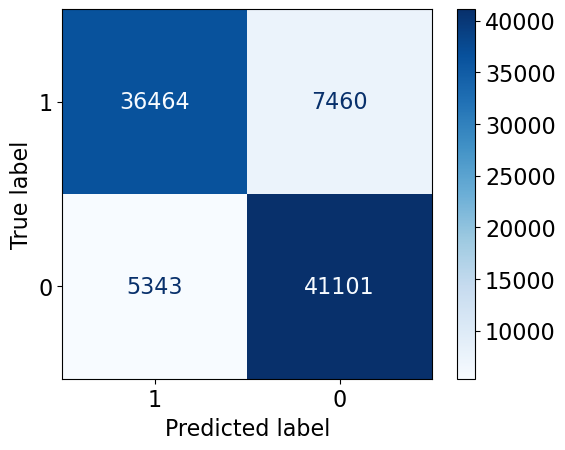

In [24]:
# Model without metadata
fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    pred_y, 
    labels=[1, 0],
    display_labels=[1, 0],
    cmap="Blues",
    ax=ax
)

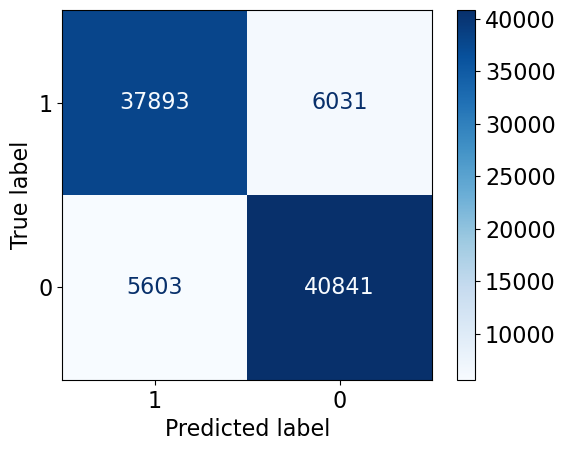

In [25]:
# Model with metadata
fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(
    y_test2, 
    pred_y_model2, 
    labels=[1, 0],
    display_labels=[1, 0],
    cmap="Blues",
    ax=ax
)

## Saving models

In [26]:
import joblib

In [27]:
joblib.dump(model,"../models/logistic_model.joblib")

['../models/logistic_model.joblib']

In [28]:
joblib.dump(model2,"../models/logistic_metadata_model.joblib")

['../models/logistic_metadata_model.joblib']